In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import ViTForImageClassification, AutoProcessor
from pathlib import Path
import os

import sys; sys.path.append("../src/")
from stability import soft_stability_rate
from models import MaskedImageClassifier, CertifiedMuSImageClassifier, discretized_mus_masks
from data_utils import load_images_from_directory,load_image_from_path
from explanations import \
    get_lime_for_image, get_shap_for_image, get_intgrad_for_image, get_mfaba_for_image
from visualizations import add_k_ones_enumerate, vis_masked_img, get_top_k_predictions, get_labels_containing_keyword
from visualizations import set_random_seed, MaskedImageClassifierNew, CertifiedMuSImageClassifierNew

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import math

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
import json
import requests

url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
labels = requests.get(url).json()

def get_imagenet_label(index):
    return labels[index] if 0 <= index < len(labels) else None


In [3]:
get_imagenet_label(282)

'tiger cat'

In [4]:
# Load images; they will be ordered the same every time.
images = load_images_from_directory("/shared_data0/helenjin/imagenet-sample-images/")
# images = images[:20]
print(images.shape)

torch.Size([1000, 3, 224, 224])


In [5]:
# Load the model. This should be our custom fine-tuned models later!
raw_vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
# saved_data = torch.load("../_saved_models/google_vit_patch16_img224_bsz128_lr0.0001_epoch5.pt")
# raw_vit.load_state_dict(saved_data["state_dict"])
raw_vit.eval().to(device);
processor = AutoProcessor.from_pretrained('google/vit-base-patch16-224')

In [6]:
# raw_vit.load_state_dict(torch.load('/shared_data0/antonxue/google_vit_patch16_img224_bsz128_lr0.0001_epoch5.pt')['state_dict'])

In [7]:
images.min(), images.max()

(tensor(-1.), tensor(1.))

In [8]:
# torch.tensor(processor(images[0])['pixel_values']).min(), torch.tensor(processor(images[0])['pixel_values']).max()

In [9]:
import torch
from torchvision.transforms import ToPILImage

# Example tensor (C, H, W) in range [0, 1]
tensor = torch.rand(3, 256, 256)  # Example RGB image

# Convert to PIL image
to_pil = ToPILImage()
pil_image = to_pil(tensor)

# Show image
# pil_image.show()


image_proc = torch.tensor(processor(to_pil(images[0]))['pixel_values'])

In [10]:
grid_size = 4

In [11]:
wrapped_vit = MaskedImageClassifierNew(raw_vit, grid_size=(grid_size,grid_size)).to(device)
wrapped_vit.eval();
cert_mus_vit = CertifiedMuSImageClassifierNew(raw_vit, lambda_=1, 
                                              grid_size=(grid_size,grid_size),
                                             quant=64).to(device)
cert_mus_vit.eval();

In [12]:
wrapped_vit.grid_size

(4, 4)

In [13]:
def check_pred_same(wrapped_vit, cert_mus_vit, image, label, alpha=None): # label = img_idx
    wrapped_vit_pred = wrapped_vit(image.to(device), alpha).argmax(-1).item()
    cert_mus_vit_pred = cert_mus_vit(image.to(device), alpha)['logits'].argmax(-1).item()
    print('wrapped_vit_pred', wrapped_vit_pred, get_imagenet_label(wrapped_vit_pred))
    print('cert_mus_vit_pred', cert_mus_vit_pred, get_imagenet_label(cert_mus_vit_pred))
    
    if wrapped_vit_pred != cert_mus_vit_pred or wrapped_vit_pred != label or cert_mus_vit_pred != label:
        # print('cont')
        return False
    return True

# Visualize

In [14]:
# [238, 215, 282, 10, 33]

In [15]:
idx = 33
print(idx)
image = images[idx][None]
# image = image * 2 - 1
image_name = f'image_{idx}'

33


In [16]:
original_image = image

torch.Size([1, 3, 224, 224])
raw_pred loggerhead, loggerhead turtle, Caretta caretta 33
smooth_pred loggerhead, loggerhead turtle, Caretta caretta 33
Rank 1: Label ID = 33, Label = loggerhead, loggerhead turtle, Caretta caretta, Logit = 11.9528, Probability = 0.5895
Rank 2: Label ID = 973, Label = coral reef, Logit = 11.4420, Probability = 0.3537
Rank 3: Label ID = 34, Label = leatherback turtle, leatherback, leathery turtle, Dermochelys coriacea, Logit = 8.3875, Probability = 0.0167
Rank 4: Label ID = 109, Label = brain coral, Logit = 7.8124, Probability = 0.0094
Rank 5: Label ID = 801, Label = snorkel, Logit = 6.9881, Probability = 0.0041
Rank 6: Label ID = 983, Label = scuba diver, Logit = 6.9359, Probability = 0.0039
Rank 7: Label ID = 6, Label = stingray, Logit = 6.3247, Probability = 0.0021
Rank 8: Label ID = 36, Label = terrapin, Logit = 5.9596, Probability = 0.0015
Rank 9: Label ID = 396, Label = lionfish, Logit = 5.8547, Probability = 0.0013
Rank 10: Label ID = 5, Label = elec

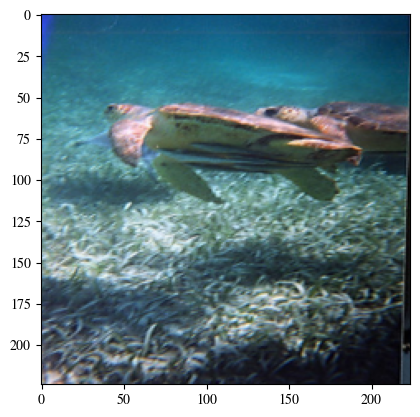

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# plt.imshow(image[0].cpu().permute(1,2,0))
plt.imshow((image[0].cpu().permute(1,2,0) + 1) /2)
raw_pred = wrapped_vit(image.cuda()).argmax(-1).item()
set_random_seed(42)
smooth_pred = cert_mus_vit(image.cuda())['logits'].argmax(-1).item()
print(image.shape)
print('raw_pred', raw_vit.config.id2label[raw_pred], raw_pred)
print('smooth_pred', raw_vit.config.id2label[smooth_pred], smooth_pred)

# get top_k predictions
top_k = 10
top_k_preds = get_top_k_predictions(wrapped_vit, image, raw_vit, k=top_k)

# Print the top k predictions
for rank, (label_id, label_name, logit, prob) in enumerate(top_k_preds, start=1):
    print(f"Rank {rank}: Label ID = {label_id}, Label = {label_name}, Logit = {logit:.4f}, Probability = {prob:.4f}")

In [18]:
plt.imshow((image[0].cpu().permute(1,2,0) + 1) /2)
plt.axis('off')
save_path = f'_dump/useful_images/{idx}/image_{idx}.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

In [19]:
num_patches=grid_size * grid_size
top_k_frac = 0.5

  0%|          | 0/1000 [00:00<?, ?it/s]

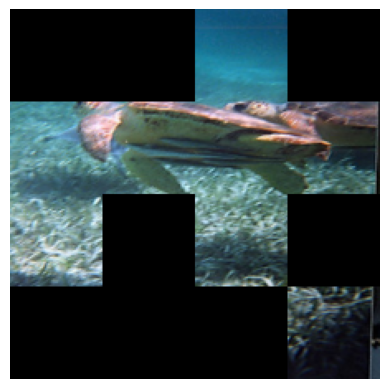

In [44]:
set_random_seed(42)
lime_expln_alpha, lime_expln, lime_expln_attrs = get_lime_for_image(wrapped_vit, 
                                                                    image[0], return_verbose=True,
                                                                   num_patches=num_patches, top_k_frac=top_k_frac)
vis_masked_img(image=image.cpu(), alpha=lime_expln_alpha.cpu(), save_path=f'_dump/useful_images/{idx}/fig1_image_{idx}_lime') 
vis_masked_img(image=image.cpu(), alpha=lime_expln_alpha.cpu()) 

In [22]:
check_pred_same(wrapped_vit, cert_mus_vit, image, label=idx, alpha=lime_expln_alpha)


wrapped_vit_pred 33 loggerhead sea turtle
cert_mus_vit_pred 33 loggerhead sea turtle


True

In [82]:
set_random_seed(42)
shap_expln_alpha, shap_expln, shap_expln_attrs = get_shap_for_image(wrapped_vit, 
                                                                        image[0], return_verbose=True,
                                                                       num_patches=num_patches, top_k_frac=top_k_frac)   
vis_masked_img(image=image.cpu(), alpha=shap_expln_alpha.cpu(), save_path=f'_dump/useful_images/{idx}/image_{idx}_shap') 
vis_masked_img(image=image.cpu(), alpha=shap_expln_alpha.cpu()) 

KeyboardInterrupt: 

In [23]:
exp = lime_expln_alpha
r = 8
ss_dict = soft_stability_rate(wrapped_vit, image[0].to(device), exp.to(device), r, epsilon=0.1, return_all=True)

In [25]:
bad_alphas = ss_dict["alpha_pertbs"][~ss_dict["matches"]].cpu()
bad_alphas.sum(dim=(1,2,3))

tensor([11, 13, 12, 13, 12, 14, 12, 15, 14])

In [27]:
bad_alphas_r = bad_alphas[bad_alphas.sum(dim=(1,2,3)) == 11]


In [28]:
for i in range(len(bad_alphas_r)):
    print(i)
    check_pred_same(wrapped_vit, cert_mus_vit, image, label=idx, alpha=bad_alphas_r[i].to(device))

0
wrapped_vit_pred 973 coral reef
cert_mus_vit_pred 973 coral reef


In [32]:
# vis_masked_img(image=image.cpu(), alpha=bad_alphas_r[0].float()) 

In [30]:
image_bad_r = 0.5 * (1 + image) * F.interpolate(bad_alphas_r.float(), size=(224,224))

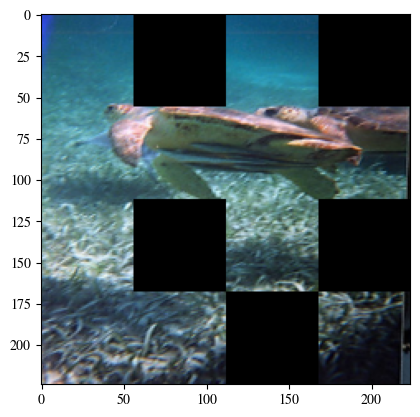

In [ ]:
plt.clf()
plt.imshow(image_bad_r[0].numpy().transpose(1,2,0))

In [45]:
# save the bad alpha example
img = image_bad_r[0]
plt.clf()
plt.imshow(img.numpy().transpose(1,2,0))
plt.axis('off')
save_path = f'_dump/useful_images/{idx}/fig1_image_{idx}_lime_bad_alpha_r3'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

In [33]:
set_random_seed(42)
bad_image = image_bad_r[0].unsqueeze(0)

# get top_k predictions
top_k = 10
top_k_preds = get_top_k_predictions(wrapped_vit, bad_image, raw_vit, k=top_k)

# Print the top k predictions
for rank, (label_id, label_name, logit, prob) in enumerate(top_k_preds, start=1):
    print(f"Rank {rank}: Label ID = {label_id}, Label = {label_name}, Probability = {prob:.4f}")

Rank 1: Label ID = 33, Label = loggerhead, loggerhead turtle, Caretta caretta, Probability = 0.5876
Rank 2: Label ID = 801, Label = snorkel, Probability = 0.1864
Rank 3: Label ID = 34, Label = leatherback turtle, leatherback, leathery turtle, Dermochelys coriacea, Probability = 0.1146
Rank 4: Label ID = 973, Label = coral reef, Probability = 0.0474
Rank 5: Label ID = 983, Label = scuba diver, Probability = 0.0065
Rank 6: Label ID = 6, Label = stingray, Probability = 0.0063
Rank 7: Label ID = 119, Label = rock crab, Cancer irroratus, Probability = 0.0059
Rank 8: Label ID = 397, Label = puffer, pufferfish, blowfish, globefish, Probability = 0.0052
Rank 9: Label ID = 36, Label = terrapin, Probability = 0.0034
Rank 10: Label ID = 109, Label = brain coral, Probability = 0.0033


In [42]:
idx = 33
i = 0
load_image_path = f'_dump/useful_images/{idx}/image_{idx}_lime.png'
load_image = load_image_from_path(load_image_path)
lime_image = 0.5 * (1 + load_image) * F.interpolate(lime_expln_alpha.cpu().unsqueeze(1).float(), size=(224,224))
lime_image = lime_image[0]

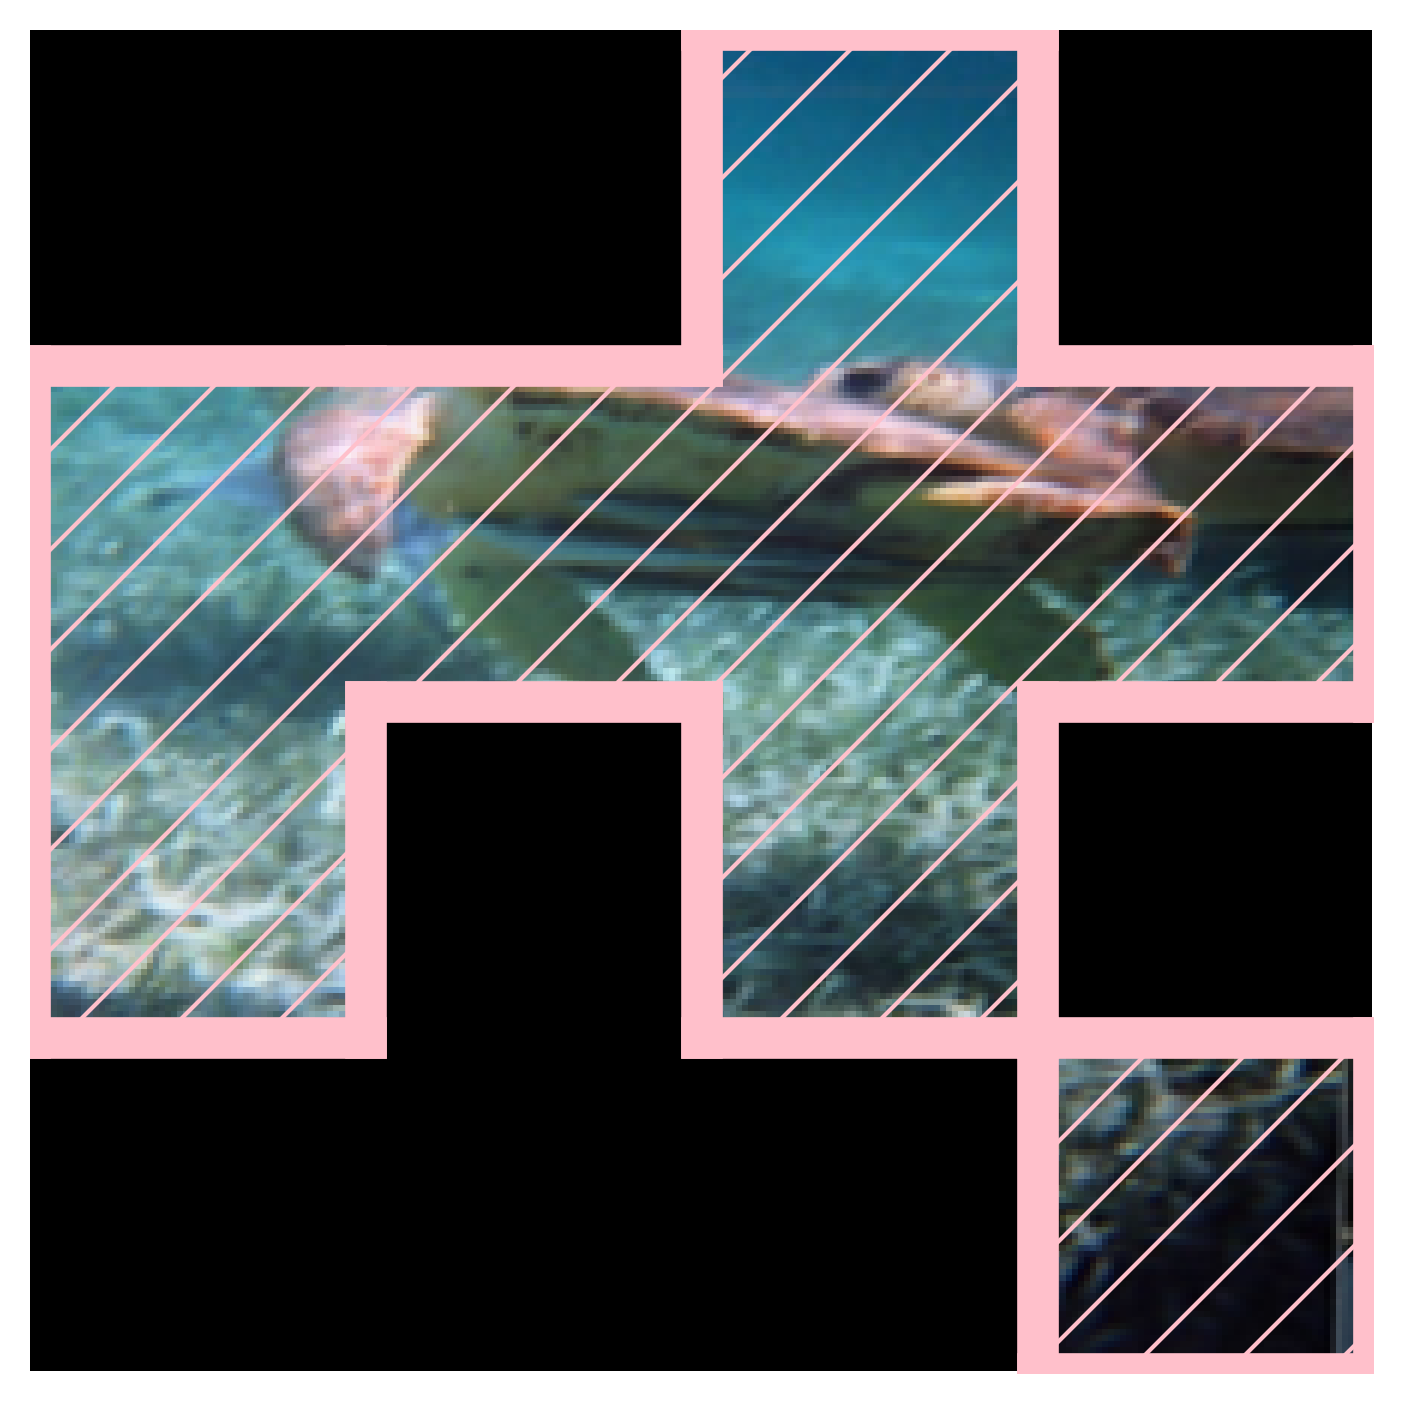

In [46]:
img = lime_image
imgi = 0
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
ax.imshow(img.numpy().transpose(1, 2, 0))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_position([0, 0, 1, 1])
ax.axis('off')
for i, j in zip(*np.where(mask == 1)):
    left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
    top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
    if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
    if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
fig.canvas.draw()
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

save_path = f'_dump/useful_images/{idx}/fig1_masked_image_{idx}_lime.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)

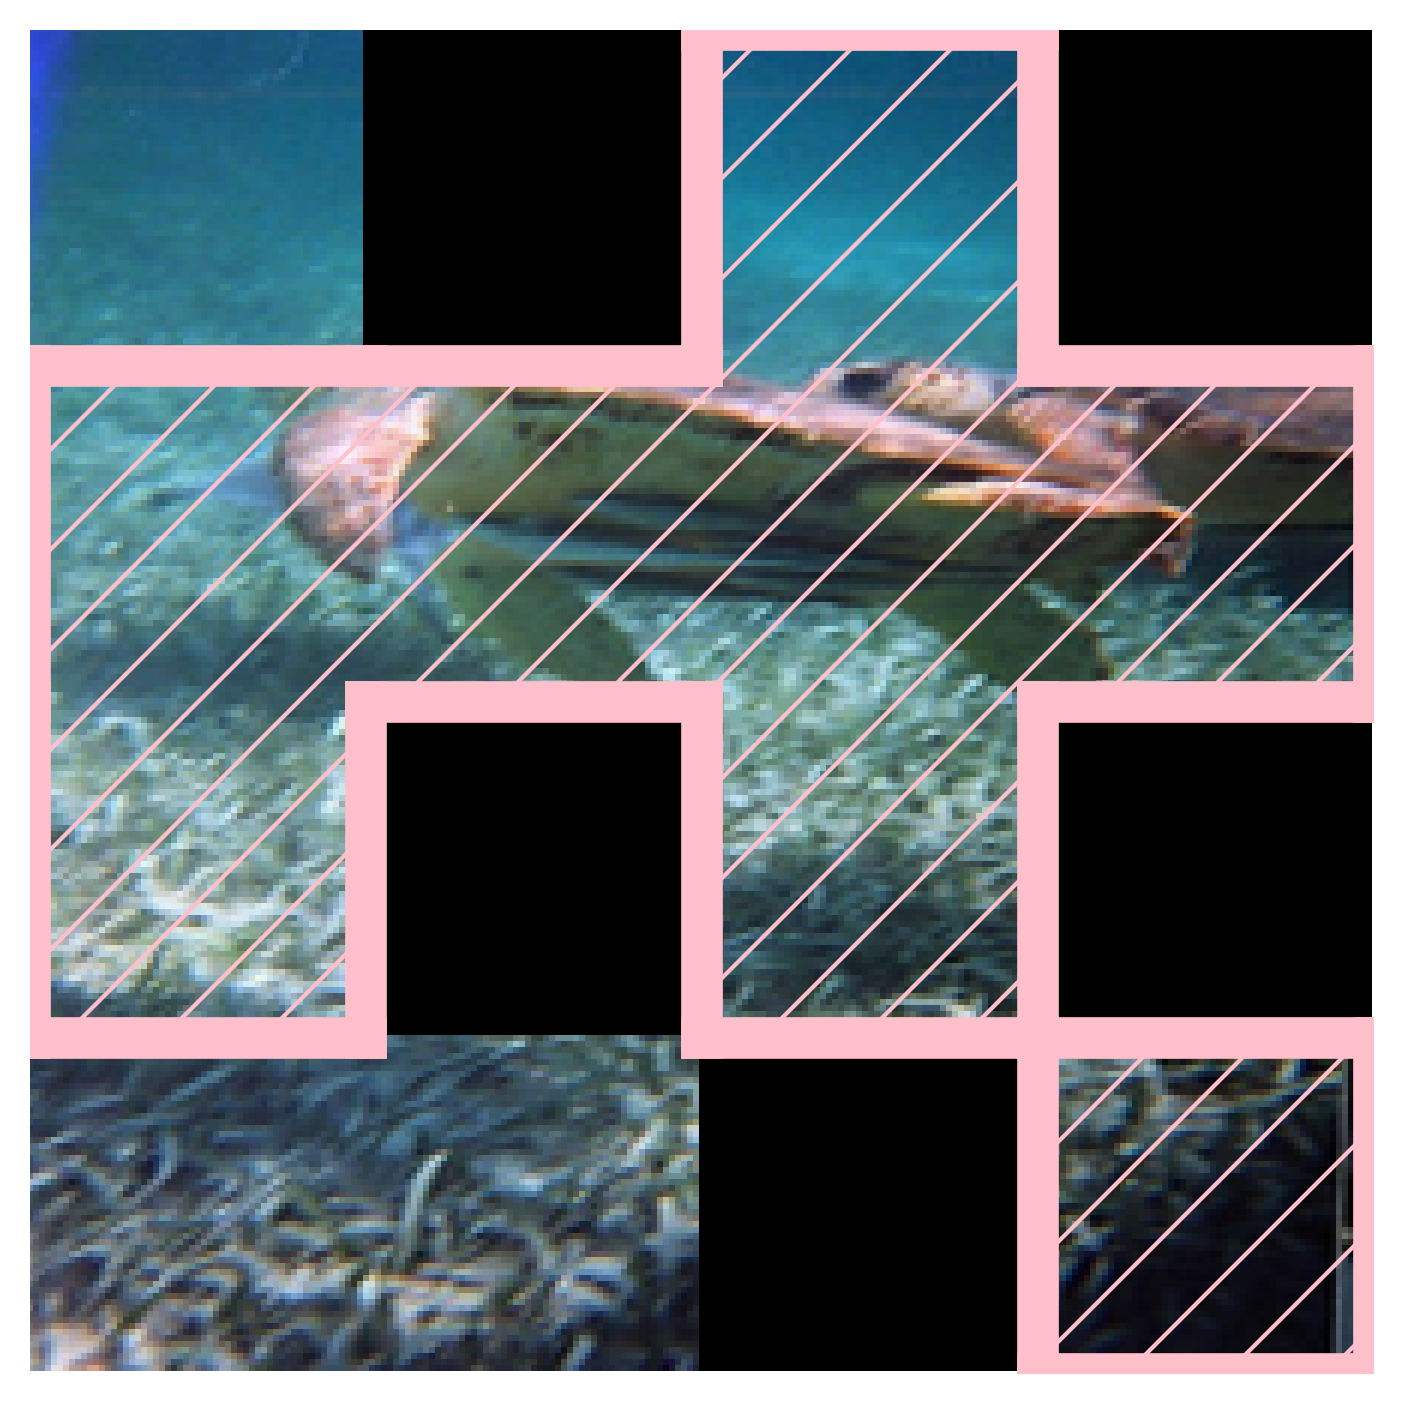

In [48]:
img = image_bad_r[0]
imgi = 0
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink' #'#009E73' #'teal'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
ax.imshow(img.numpy().transpose(1, 2, 0))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_position([0, 0, 1, 1])
ax.axis('off')
for i, j in zip(*np.where(mask == 1)):
    left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
    top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
    if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
    if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
fig.canvas.draw()
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

save_path = f'_dump/useful_images/{idx}/fig1_masked_image_{idx}_lime_bad_alpha_r1_{imgi}.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)

In [45]:
idx = 238
i = 0
load_image_path = f'_dump/useful_images/{idx}/image_{idx}_lime.png'
load_image = load_image_from_path(load_image_path)
lime_image = 0.5 * (1 + load_image) * F.interpolate(lime_expln_alpha.cpu().unsqueeze(1).float(), size=(224,224))
lime_image = lime_image[0]

In [46]:
lime_expln_alpha.shape

torch.Size([1, 4, 4])

In [47]:
bad_alphas_r3.shape

torch.Size([409, 1, 4, 4])

In [49]:
lime_image.shape

torch.Size([3, 224, 224])

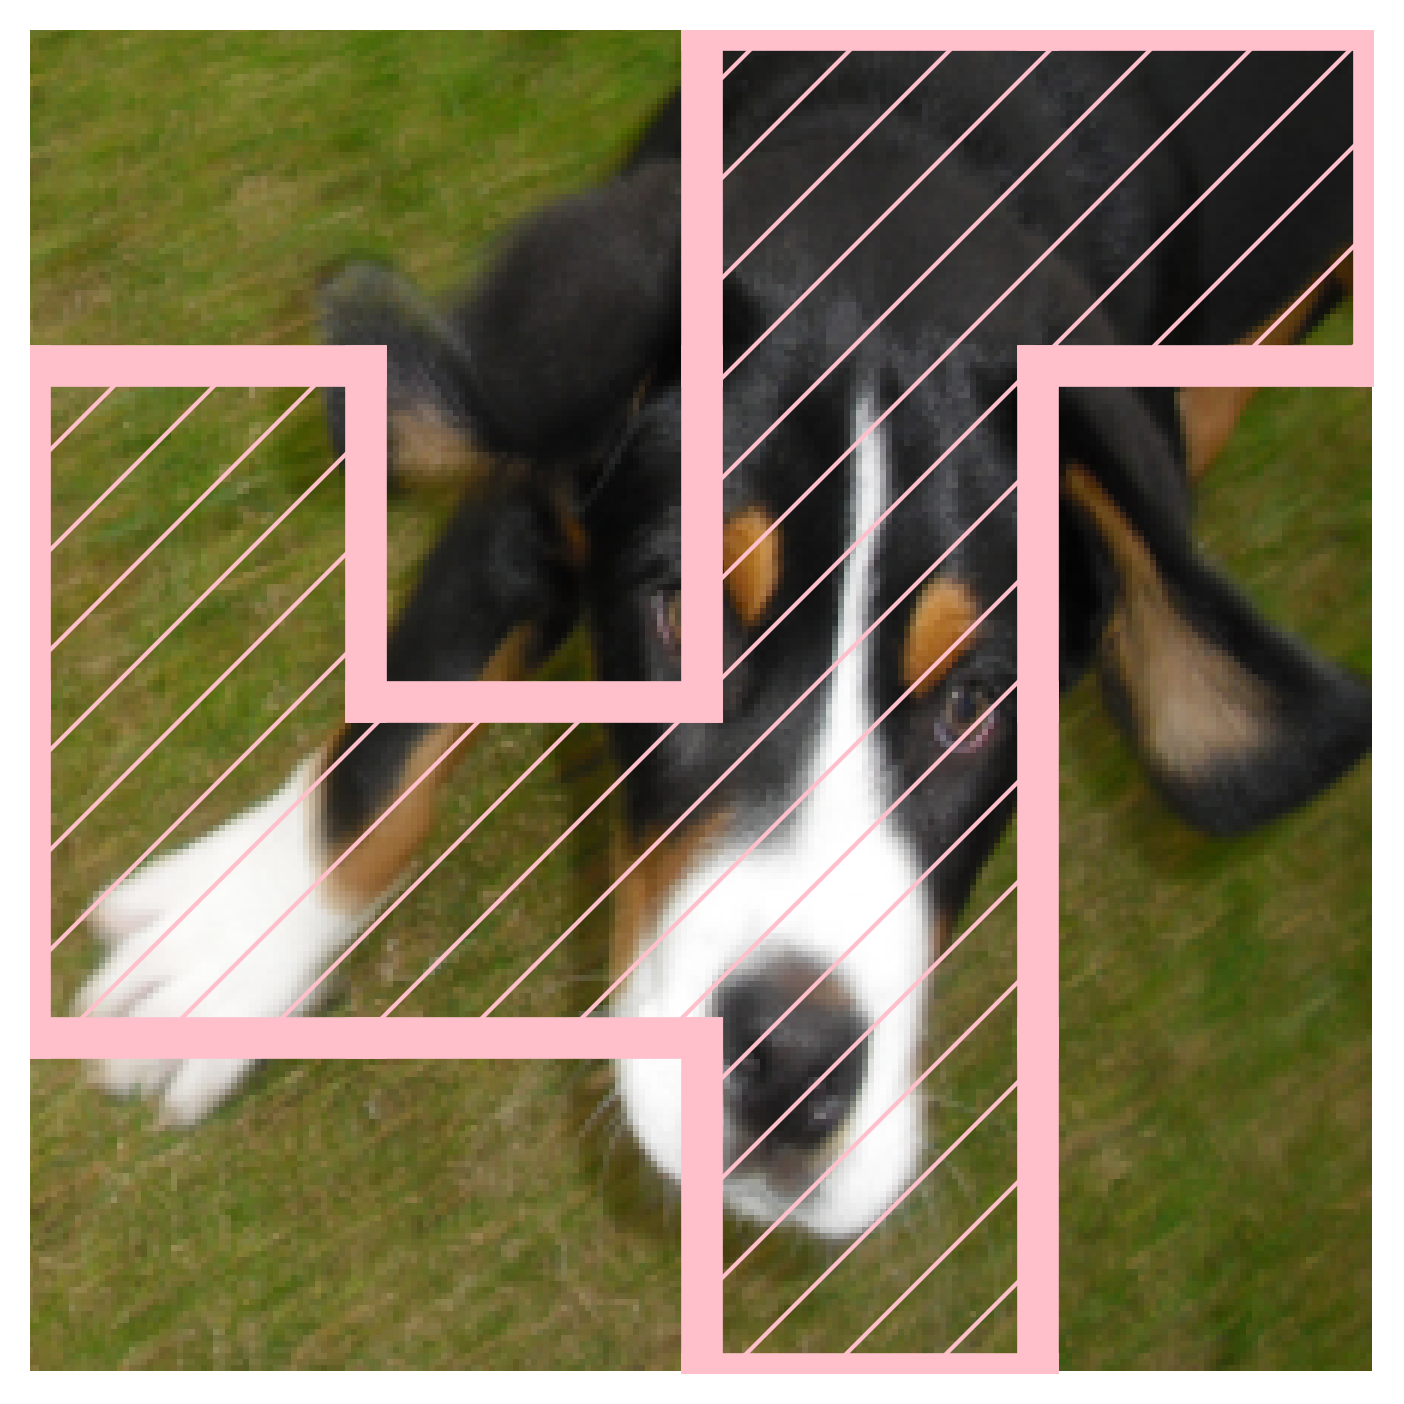

In [72]:
idx = 238
i = 0
image = 0.5 * (1 + original_image) 
img = image[0]
imgi = 0
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
ax.imshow(img.numpy().transpose(1, 2, 0))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_position([0, 0, 1, 1])
ax.axis('off')
for i, j in zip(*np.where(mask == 1)):
    left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
    top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
    if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
    if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
fig.canvas.draw()
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r8.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


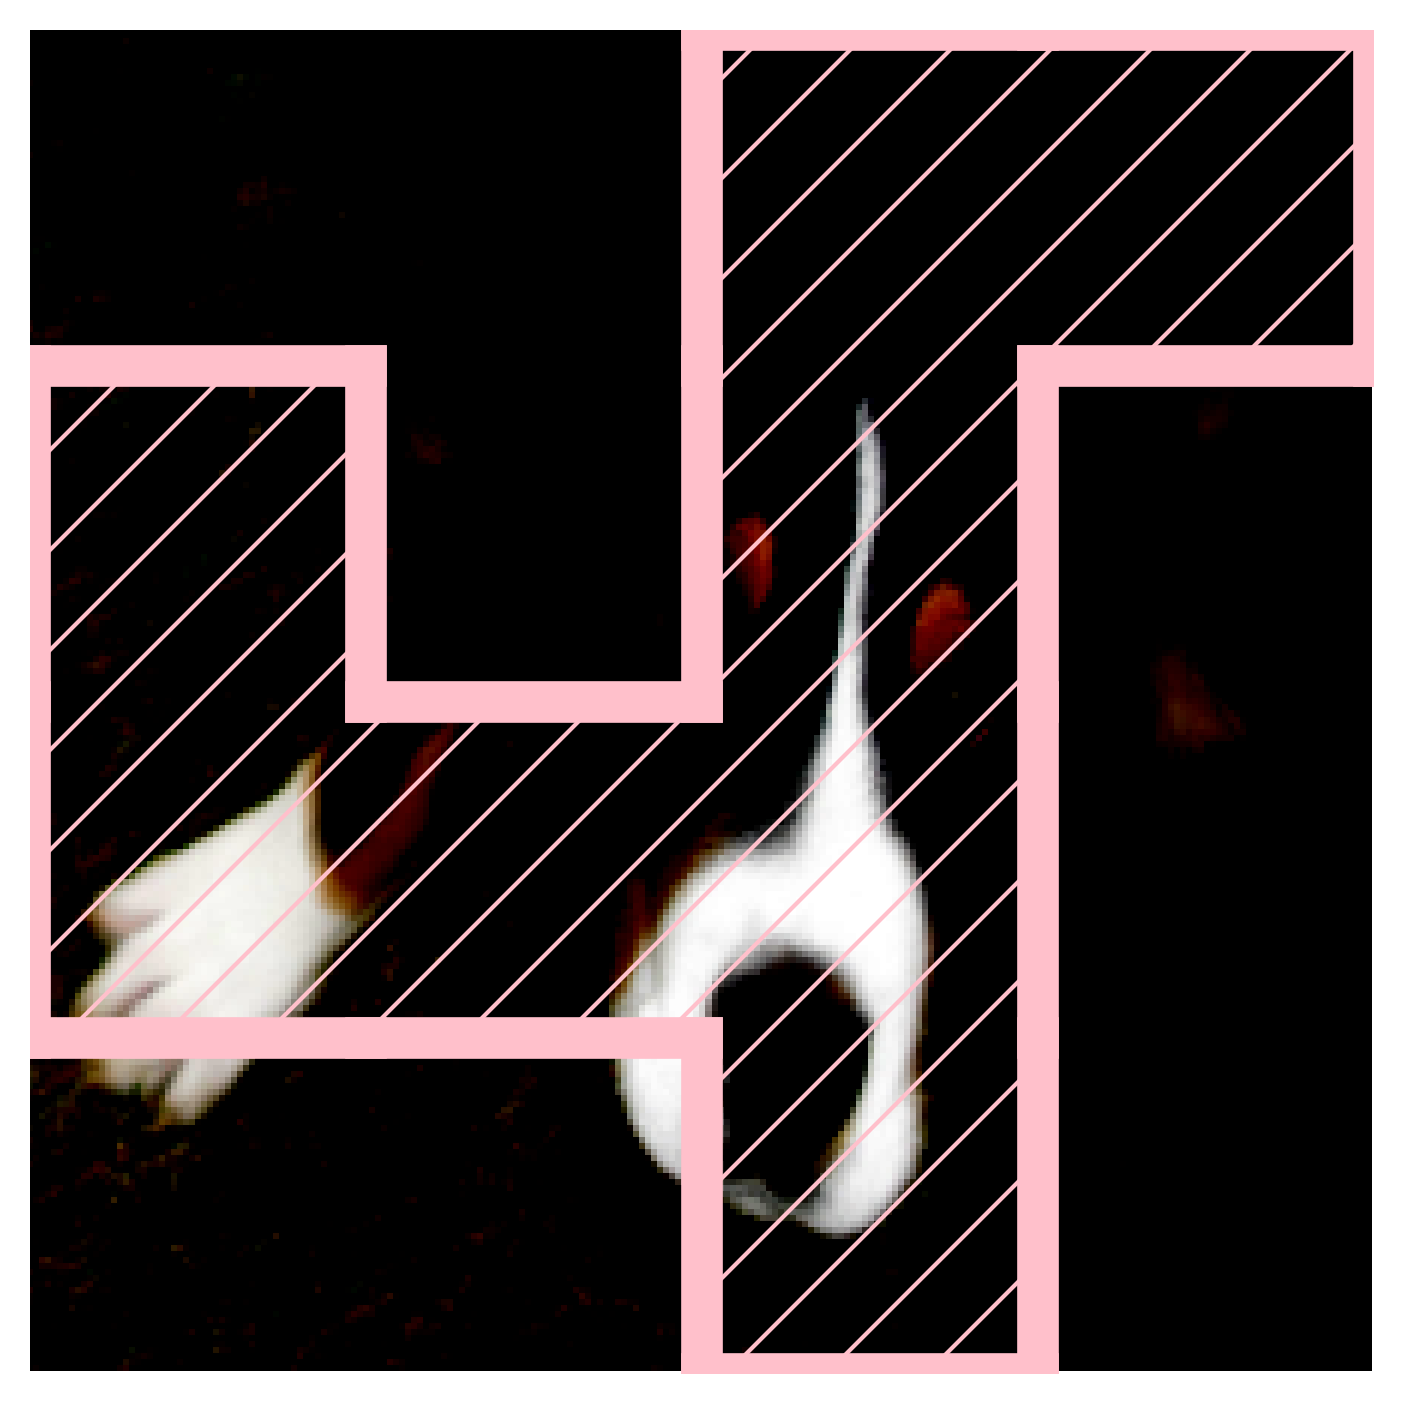

In [57]:
img = lime_image
imgi = 0
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
ax.imshow(img.numpy().transpose(1, 2, 0))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_position([0, 0, 1, 1])
ax.axis('off')
for i, j in zip(*np.where(mask == 1)):
    left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
    top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
    if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
    if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
fig.canvas.draw()
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

# save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime.png'
# os.makedirs(os.path.dirname(save_path), exist_ok=True)
# plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)

In [40]:
idx = 238
i = 0
load_image_path = f'_dump/useful_images/{idx}/image_{idx}_lime_good_alpha_r1_{i}.png'
load_image = load_image_from_path(load_image_path)

In [41]:
ss_dict = torch.load(f'_dump/useful_images/{idx}/ss_dict.pt')
ss_dict.keys()

dict_keys(['soft_stability_rate', 'y', 'y_pertbs', 'alpha_pertbs', 'matches'])

In [42]:
ss_dict['alpha_pertbs'].shape

torch.Size([14979, 1, 4, 4])

In [57]:
good_alphas_r1[0].squeeze()

tensor([[0, 0, 1, 1],
        [1, 0, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 1, 1]])

(-0.5, 223.5, 223.5, -0.5)

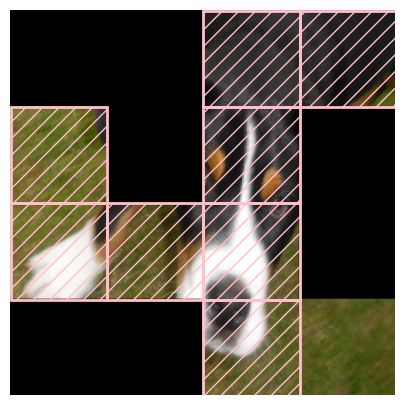

In [107]:
img = image_good_r1s[0]
mask = lime_expln_alpha.cpu().squeeze()

ig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img.numpy().transpose(1,2,0))

for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle(
        (j * patch_size, i * patch_size), patch_size, patch_size,
        linewidth=2, edgecolor='pink', facecolor='none', hatch='//'
      ))

ax.axis('off')

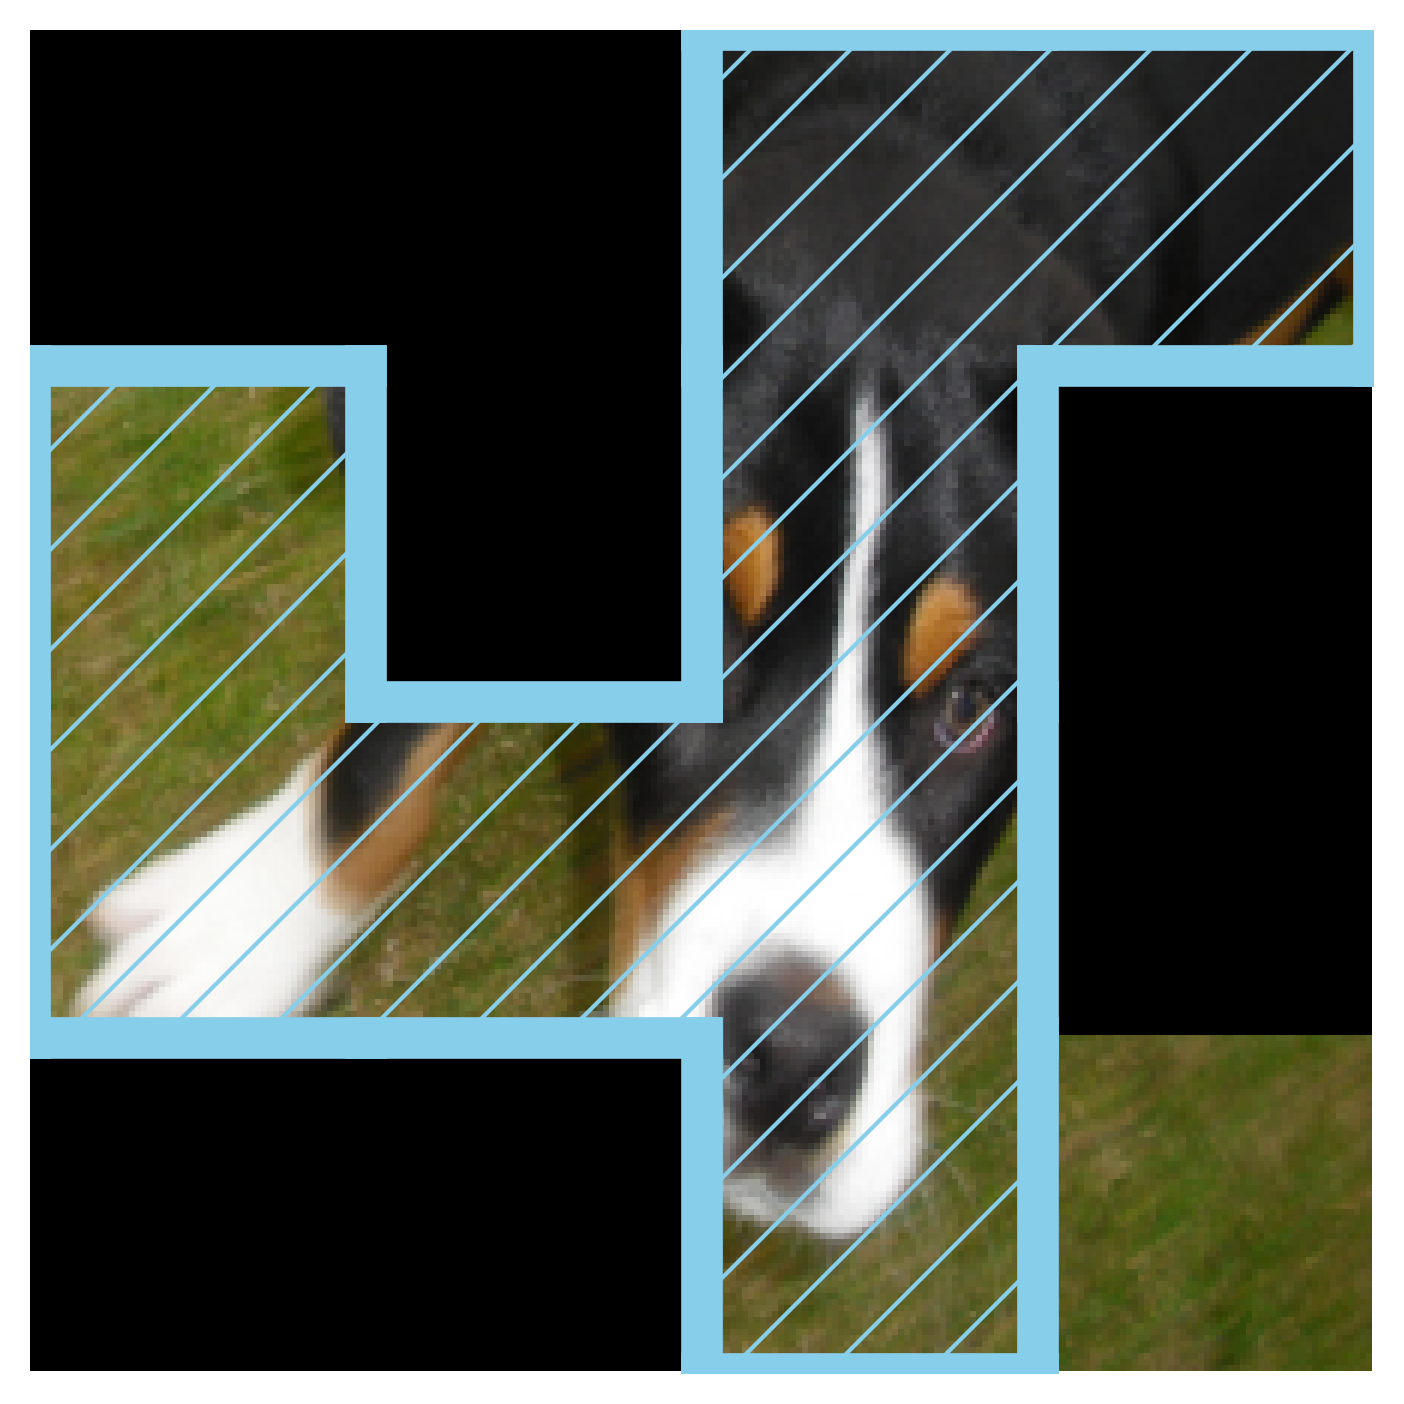

In [215]:
img = image_good_r1s[0]
imgi = 0
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'skyblue' #'#009E73' #'teal'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
ax.imshow(img.numpy().transpose(1, 2, 0))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_position([0, 0, 1, 1])
ax.axis('off')
for i, j in zip(*np.where(mask == 1)):
    left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
    top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
    if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
    if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
for i, j in zip(*np.where(mask == 1)):
    ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
fig.canvas.draw()
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r1_{imgi}.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

# for imgi, img in enumerate(image_good_r1s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r1_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()
    

# for imgi, img in enumerate(image_good_r2s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r2_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

# for imgi, img in enumerate(image_good_r3s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r3_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

# for imgi, img in enumerate(image_good_r4s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r4_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

# for imgi, img in enumerate(image_good_r5s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r5_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

for imgi, img in enumerate(image_good_r6s):
    fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
    ax.imshow(img.numpy().transpose(1, 2, 0))
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    ax.set_position([0, 0, 1, 1])
    ax.axis('off')
    for i, j in zip(*np.where(mask == 1)):
        left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
        top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
        if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
        if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    for i, j in zip(*np.where(mask == 1)):
        ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
    fig.canvas.draw()
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r6_{imgi}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
    plt.close()


for imgi, img in enumerate(image_good_r7s):
    fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
    ax.imshow(img.numpy().transpose(1, 2, 0))
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    ax.set_position([0, 0, 1, 1])
    ax.axis('off')
    for i, j in zip(*np.where(mask == 1)):
        left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
        top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
        if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
        if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    for i, j in zip(*np.where(mask == 1)):
        ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
    fig.canvas.draw()
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_good_alpha_r7_{imgi}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
    plt.close()

In [54]:
HIGH_DPI = 300  # Increase for better quality
SCALE_FACTOR = 2  # Adjust to make figure larger
mask = lime_expln_alpha.cpu().squeeze()
color = 'pink'
linewidth = 10
hatch = '/'
img_h, img_w = img.shape[1], img.shape[2]
patch_size = img_h / grid_size 

# for imgi, img in enumerate(image_bad_r3s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_bad_alpha_r3_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

# for imgi, img in enumerate(image_bad_r4s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_bad_alpha_r4_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()

# for imgi, img in enumerate(image_bad_r5s):
#     fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
#     ax.imshow(img.numpy().transpose(1, 2, 0))
#     ax.set_xlim(0, img_w)
#     ax.set_ylim(img_h, 0)
#     ax.set_position([0, 0, 1, 1])
#     ax.axis('off')
#     for i, j in zip(*np.where(mask == 1)):
#         left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
#         top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
#         if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
#         if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#         if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
#     for i, j in zip(*np.where(mask == 1)):
#         ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
#     fig.canvas.draw()
#     bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#     save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_bad_alpha_r5_{imgi}.png'
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
#     plt.close()


for imgi, img in enumerate(image_bad_r6s):
    fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
    ax.imshow(img.numpy().transpose(1, 2, 0))
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    ax.set_position([0, 0, 1, 1])
    ax.axis('off')
    for i, j in zip(*np.where(mask == 1)):
        left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
        top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
        if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
        if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    for i, j in zip(*np.where(mask == 1)):
        ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
    fig.canvas.draw()
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_bad_alpha_r6_{imgi}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
    plt.close()
    
for imgi, img in enumerate(image_bad_r7s):
    fig, ax = plt.subplots(figsize=(SCALE_FACTOR * img_w / 100, SCALE_FACTOR * img_h / 100), dpi=HIGH_DPI)
    ax.imshow(img.numpy().transpose(1, 2, 0))
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    ax.set_position([0, 0, 1, 1])
    ax.axis('off')
    for i, j in zip(*np.where(mask == 1)):
        left, right = j == 0 or mask[i, j - 1] == 0, j == mask.shape[1] - 1 or mask[i, j + 1] == 0
        top, bottom = i == 0 or mask[i - 1, j] == 0, i == mask.shape[0] - 1 or mask[i + 1, j] == 0
        if top: ax.plot([j * patch_size, (j + 1) * patch_size], [i * patch_size, i * patch_size], color=color, linewidth=linewidth)
        if bottom: ax.plot([j * patch_size, (j + 1) * patch_size], [(i + 1) * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if left: ax.plot([j * patch_size, j * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
        if right: ax.plot([(j + 1) * patch_size, (j + 1) * patch_size], [i * patch_size, (i + 1) * patch_size], color=color, linewidth=linewidth)
    for i, j in zip(*np.where(mask == 1)):
        ax.add_patch(patches.Rectangle((j * patch_size, i * patch_size), patch_size, patch_size, linewidth=0, edgecolor=color, facecolor='none', hatch=hatch))
    fig.canvas.draw()
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    save_path = f'_dump/useful_images/{idx}/masked_image_{idx}_lime_bad_alpha_r7_{imgi}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=HIGH_DPI, bbox_inches=bbox, pad_inches=0, transparent=True)
    plt.close()